In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import warnings
warnings.filterwarnings('ignore')

In [2]:

# Define paths
train_dir = 'Training/'
test_dir = 'Testing/'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
# Function to load images and labels
def load_images_and_labels(data_dir, classes, image_size=(64, 64)):
    """Load images from directory and convert to feature vectors"""
    X = []
    y = []
    for i, cls in enumerate(classes):
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.exists(cls_dir):
            print(f"Warning: Directory {cls_dir} not found")
            continue
        
        img_count = 0
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            try:
                img = Image.open(img_path).convert('L')  # Convert to grayscale
                img = img.resize(image_size)  # Resize to fixed size
                img_array = np.array(img).flatten()  # Flatten the image
                X.append(img_array)
                y.append(i)
                img_count += 1
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
        
        print(f"Loaded {img_count} images from class {cls}")
    
    return np.array(X), np.array(y)

In [4]:
# Define paths and class names
train_dir = 'Training/'
test_dir = 'Testing/'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Load complete training set
print("Loading training set...")
X_train_full, y_train_full = load_images_and_labels(train_dir, classes, image_size=(64, 64))
print(f"Total training set loaded: {X_train_full.shape[0]} samples, {X_train_full.shape[1]} features each")
print(f"Class distribution: {np.bincount(y_train_full)}")

Loading training set...
Loaded 1400 images from class glioma
Loaded 1400 images from class meningioma
Loaded 1400 images from class notumor
Loaded 1400 images from class pituitary
Total training set loaded: 5600 samples, 4096 features each
Class distribution: [1400 1400 1400 1400]


In [5]:
# Split training set into train (70%) and validation (30%)
print("\nSplitting training data into train and validation sets (70:30)...")
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.3, 
    random_state=42,
    stratify=y_train_full
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Validation class distribution: {np.bincount(y_val)}")


Splitting training data into train and validation sets (70:30)...
Training set: 3920 samples
Validation set: 1680 samples
Training class distribution: [980 980 980 980]
Validation class distribution: [420 420 420 420]


In [6]:
# Hyperparameter tuning using GridSearchCV
print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# First, apply PCA with initial components
print("\nApplying initial PCA...")
pca_initial = PCA(n_components=200)
X_train_pca_initial = pca_initial.fit_transform(X_train)
X_val_pca_initial = pca_initial.transform(X_val)

print(f"Explained variance ratio (first 20 components): {np.sum(pca_initial.explained_variance_ratio_[:20]):.4f}")

# Define hyperparameter grid for SVM
print("\nTuning SVM hyperparameters...")
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'poly']
}

# GridSearchCV for SVM
print("Running GridSearchCV (this may take a few minutes)...")
svm = SVC(probability=True, random_state=42)
grid_search = GridSearchCV(
    svm, param_grid, 
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_pca_initial, y_train)

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation F1 (macro) score: {grid_search.best_score_:.4f}")

best_svm = grid_search.best_estimator_

# Validate on validation set
y_val_pred = best_svm.predict(X_val_pca_initial)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')

print(f"\nValidation Set Results:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Macro F1 Score: {val_f1_macro:.4f}")


HYPERPARAMETER TUNING

Applying initial PCA...
Explained variance ratio (first 20 components): 0.5723

Tuning SVM hyperparameters...
Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters found: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation F1 (macro) score: 0.9133

Validation Set Results:
Accuracy: 0.9304
Macro F1 Score: 0.9297


In [7]:
# Tune PCA components using validation set
print("\n" + "="*60)
print("TUNING PCA COMPONENTS")
print("="*60)

best_val_f1 = 0
best_n_components = 100
results_pca = []

print("\nTesting PCA with different numbers of components...")
for n_comp in [50, 100, 150, 200, 250, 300, 350, 400]:
    pca_test = PCA(n_components=n_comp)
    X_train_pca_test = pca_test.fit_transform(X_train)
    X_val_pca_test = pca_test.transform(X_val)
    
    # Train SVM with best parameters
    svm_test = SVC(**grid_search.best_params_, probability=True, random_state=42)
    svm_test.fit(X_train_pca_test, y_train)
    
    y_val_pred_test = svm_test.predict(X_val_pca_test)
    val_f1_test = f1_score(y_val_pred_test, y_val, average='macro')
    val_acc_test = accuracy_score(y_val, y_val_pred_test)
    
    results_pca.append({
        'n_components': n_comp,
        'accuracy': val_acc_test,
        'f1_macro': val_f1_test,
        'explained_variance': np.sum(pca_test.explained_variance_ratio_)
    })
    
    print(f"Components: {n_comp:3d} | Accuracy: {val_acc_test:.4f} | F1 (macro): {val_f1_test:.4f} | Exp. Var: {np.sum(pca_test.explained_variance_ratio_):.4f}")
    
    if val_f1_test > best_val_f1:
        best_val_f1 = val_f1_test
        best_n_components = n_comp

print(f"\nBest PCA components: {best_n_components} (F1 macro: {best_val_f1:.4f})")

# Train final model with best parameters
print(f"\nTraining final model with best hyperparameters...")
pca_final = PCA(n_components=best_n_components)
X_train_pca_final = pca_final.fit_transform(X_train)
X_val_pca_final = pca_final.transform(X_val)

svm_final = SVC(**grid_search.best_params_, probability=True, random_state=42)
svm_final.fit(X_train_pca_final, y_train)

print("Final model trained successfully!")


TUNING PCA COMPONENTS

Testing PCA with different numbers of components...
Components:  50 | Accuracy: 0.9190 | F1 (macro): 0.9188 | Exp. Var: 0.6913
Components: 100 | Accuracy: 0.9321 | F1 (macro): 0.9317 | Exp. Var: 0.7851
Components: 150 | Accuracy: 0.9280 | F1 (macro): 0.9274 | Exp. Var: 0.8369
Components: 200 | Accuracy: 0.9286 | F1 (macro): 0.9279 | Exp. Var: 0.8706
Components: 250 | Accuracy: 0.9304 | F1 (macro): 0.9296 | Exp. Var: 0.8944
Components: 300 | Accuracy: 0.9292 | F1 (macro): 0.9284 | Exp. Var: 0.9124
Components: 350 | Accuracy: 0.9286 | F1 (macro): 0.9278 | Exp. Var: 0.9263
Components: 400 | Accuracy: 0.9298 | F1 (macro): 0.9291 | Exp. Var: 0.9368

Best PCA components: 100 (F1 macro: 0.9317)

Training final model with best hyperparameters...
Final model trained successfully!


In [8]:
# Load and evaluate on test set
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

print("\nLoading test set...")
X_test, y_test = load_images_and_labels(test_dir, classes, image_size=(64, 64))
print(f"Test set loaded: {X_test.shape[0]} samples")
print(f"Test class distribution: {np.bincount(y_test)}")

# Apply PCA to test set
print("\nApplying PCA transformation to test set...")
X_test_pca_final = pca_final.transform(X_test)

# Predictions on test set
print("Generating predictions on test set...")
y_test_pred = svm_final.predict(X_test_pca_final)
y_test_pred_proba = svm_final.decision_function(X_test_pca_final)

print("\n" + "-"*60)
print("PERFORMANCE METRICS - TEST SET")
print("-"*60)

# Basic metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision_macro = precision_score(y_test, y_test_pred, average='macro')
test_recall_macro = recall_score(y_test, y_test_pred, average='macro')
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')

print(f"\nAccuracy: {test_accuracy:.4f}")
print(f"Precision (macro): {test_precision_macro:.4f}")
print(f"Recall (macro): {test_recall_macro:.4f}")
print(f"F1 Score (macro): {test_f1_macro:.4f}")

# Per-class metrics
print("\n" + "-"*60)
print("PER-CLASS METRICS")
print("-"*60)
print(classification_report(y_test, y_test_pred, target_names=classes))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Macro ROC AUC (One-vs-Rest)
print("\n" + "-"*60)
print("MACRO ROC AUC - ONE-VS-REST")
print("-"*60)

y_test_bin = np.zeros((y_test.size, len(classes)))
for i in range(len(classes)):
    y_test_bin[:, i] = (y_test == i).astype(int)

fpr = dict()
tpr = dict()
roc_auc_scores = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_pred_proba[:, i])
    roc_auc_scores[i] = auc(fpr[i], tpr[i])
    print(f"{classes[i]}: {roc_auc_scores[i]:.4f}")

macro_roc_auc = np.mean(list(roc_auc_scores.values()))
print(f"\nMacro ROC AUC: {macro_roc_auc:.4f}")


TEST SET EVALUATION

Loading test set...
Loaded 400 images from class glioma
Loaded 400 images from class meningioma
Loaded 400 images from class notumor
Loaded 400 images from class pituitary
Test set loaded: 1600 samples
Test class distribution: [400 400 400 400]

Applying PCA transformation to test set...
Generating predictions on test set...

------------------------------------------------------------
PERFORMANCE METRICS - TEST SET
------------------------------------------------------------

Accuracy: 0.8819
Precision (macro): 0.8828
Recall (macro): 0.8819
F1 Score (macro): 0.8795

------------------------------------------------------------
PER-CLASS METRICS
------------------------------------------------------------
              precision    recall  f1-score   support

      glioma       0.87      0.76      0.81       400
  meningioma       0.89      0.81      0.85       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.93      0.96      0.95    


Generating visualizations...


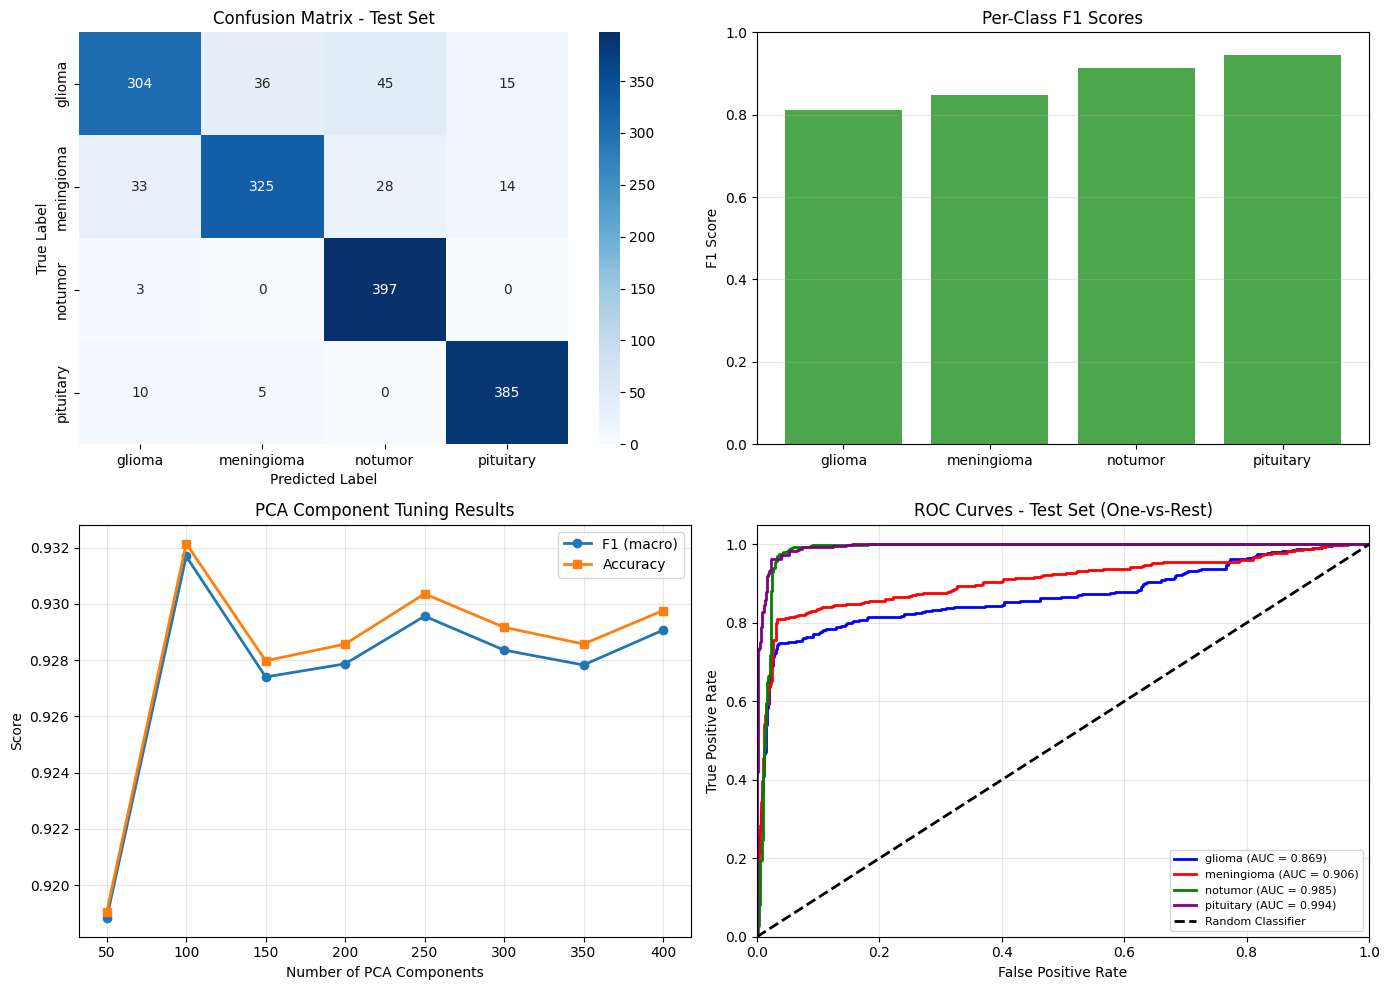

Visualizations complete!


In [9]:
# Visualizations
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix Heatmap
ax = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title('Confusion Matrix - Test Set')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# 2. Per-class F1 scores
ax = axes[0, 1]
f1_per_class = f1_score(y_test, y_test_pred, average=None)
colors = ['green' if f1 > 0.8 else 'orange' if f1 > 0.7 else 'red' for f1 in f1_per_class]
ax.bar(classes, f1_per_class, color=colors, alpha=0.7)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Scores')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# 3. PCA components tuning results
ax = axes[1, 0]
results_df = pd.DataFrame(results_pca)
ax.plot(results_df['n_components'], results_df['f1_macro'], marker='o', label='F1 (macro)', linewidth=2)
ax.plot(results_df['n_components'], results_df['accuracy'], marker='s', label='Accuracy', linewidth=2)
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Score')
ax.set_title('PCA Component Tuning Results')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. ROC Curves (multi-class)
ax = axes[1, 1]
colors_cycle = cycle(['blue', 'red', 'green', 'purple'])

for i, color in zip(range(len(classes)), colors_cycle):
    ax.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{classes[i]} (AUC = {roc_auc_scores[i]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Test Set (One-vs-Rest)')
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations complete!")

In [10]:
# Summary Report
print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY REPORT")
print("="*60)

summary_data = {
    'Metric': [
        'Total Training Samples',
        'Validation Samples',
        'Test Samples',
        'Best PCA Components',
        'SVM Kernel',
        'SVM C Parameter',
        'SVM Gamma Parameter',
        '---',
        'Train Accuracy',
        'Validation Accuracy',
        'Test Accuracy',
        'Test Precision (macro)',
        'Test Recall (macro)',
        'Test F1 Score (macro)',
        'Test Macro ROC AUC'
    ],
    'Value': [
        f"{X_train.shape[0]}",
        f"{X_val.shape[0]}",
        f"{X_test.shape[0]}",
        f"{best_n_components}",
        f"{grid_search.best_params_.get('kernel', 'N/A')}",
        f"{grid_search.best_params_.get('C', 'N/A')}",
        f"{grid_search.best_params_.get('gamma', 'N/A')}",
        '---',
        f"{accuracy_score(y_train, svm_final.predict(X_train_pca_final)):.4f}",
        f"{accuracy_score(y_val, svm_final.predict(X_val_pca_final)):.4f}",
        f"{test_accuracy:.4f}",
        f"{test_precision_macro:.4f}",
        f"{test_recall_macro:.4f}",
        f"{test_f1_macro:.4f}",
        f"{macro_roc_auc:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*60)
print("CLASS-WISE PERFORMANCE ON TEST SET")
print("="*60)
for i, cls in enumerate(classes):
    class_f1 = f1_score(y_test, y_test_pred, labels=[i], average='macro')
    class_acc = np.sum((y_test == i) & (y_test_pred == i)) / np.sum(y_test == i) if np.sum(y_test == i) > 0 else 0
    class_samples = np.sum(y_test == i)
    print(f"\n{cls.upper()}")
    print(f"  Test samples: {class_samples}")
    print(f"  Class accuracy: {class_acc:.4f}")
    print(f"  ROC AUC: {roc_auc_scores[i]:.4f}")


COMPREHENSIVE SUMMARY REPORT

                Metric  Value
Total Training Samples   3920
    Validation Samples   1680
          Test Samples   1600
   Best PCA Components    100
            SVM Kernel    rbf
       SVM C Parameter    100
   SVM Gamma Parameter  scale
                   ---    ---
        Train Accuracy 1.0000
   Validation Accuracy 0.9321
         Test Accuracy 0.8819
Test Precision (macro) 0.8828
   Test Recall (macro) 0.8819
 Test F1 Score (macro) 0.8795
    Test Macro ROC AUC 0.9384

CLASS-WISE PERFORMANCE ON TEST SET

GLIOMA
  Test samples: 400
  Class accuracy: 0.7600
  ROC AUC: 0.8688

MENINGIOMA
  Test samples: 400
  Class accuracy: 0.8125
  ROC AUC: 0.9063

NOTUMOR
  Test samples: 400
  Class accuracy: 0.9925
  ROC AUC: 0.9847

PITUITARY
  Test samples: 400
  Class accuracy: 0.9625
  ROC AUC: 0.9940
